In [1]:
import math
from functools import partial
from collections import Counter, defaultdict

import io
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou
from torchvision.models.detection.anchor_utils import AnchorGenerator

from torchmetrics.detection import MeanAveragePrecision


In [2]:
# Если запускаете из коллаба
# pip install torchmetrics

In [3]:
# Определяем константы для цвета и названий классов
class_to_color = {
    1: (89, 161, 197),
    2: (204, 79, 135),
    3: (125, 216, 93),
    4: (175, 203, 33),
}

class_to_name = {
    1: "enemy",
    2: "enemy-head",
    3: "friendly",
    4: "friendly-head"
}

## Загрузка данных

Сделал универсальную загрузку локальную и из huggingface. По результату локальная загрузка не работает - не совпадает формат

In [4]:
from datasets import load_from_disk


class Load_ds:
    ds = None  # Статическая переменная класса

    def __init__(self, path='..\\halo-infinite-angel-videogame'):
        self.path = path
        self.start()

    def get_train(self):
        return pd.DataFrame(Load_ds.ds['train'])

    def get_test(self):
        return pd.DataFrame(Load_ds.ds['test'])

    def start(self):
        if Load_ds.ds is None:
            Load_ds.ds = load_from_disk(self.path)


class Download_ds:

    def __init__(self):
        self.splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
                       'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
                       'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}

    def get_train(self):
        return pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + self.splits["train"])

    def get_test(self):
        return pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + self.splits["test"])

### локальная

In [5]:
if 0:
    ld = Load_ds()
    df_train = ld.get_train()
    df_test = ld.get_test()

### из huggingface

In [6]:
if 1:
    ld = Download_ds()
    df_train = ld.get_train()
    df_test = ld.get_test()

## Функции отрисовки данных

In [7]:
# Вспомогательные функции для отрисовки данных
def add_bbox(image, box, label='', color=(128, 128, 128), txt_color=(0, 0, 0)):
    lw = max(round(sum(image.shape) / 2 * 0.003), 2)
    p1, p2 = (int(box[0]), int(box[1])), (int(box[0]) + int(box[2]), int(box[1]) + int(box[3]))
    cv2.rectangle(image, p1, p2, color, thickness=lw, lineType=cv2.LINE_AA)
    if label:
        tf = max(lw - 1, 1)
        w, h = cv2.getTextSize(label, 0, fontScale=lw / 3, thickness=tf)[0]
        outside = p1[1] - h >= 3
        p2 = p1[0] + w, p1[1] - h - 3 if outside else p1[1] + h + 3
        cv2.rectangle(image, p1, p2, color, -1, cv2.LINE_AA)
        cv2.putText(image,
                    label, (p1[0], p1[1] - 2 if outside else p1[1] + h + 2),
                    0,
                    lw / 3,
                    txt_color,
                    thickness=tf,
                    lineType=cv2.LINE_AA)
    return image


def plot_examples(df, indices=None, num_examples=6, row_figsize=(12, 3)):
    if indices is None:
        indices = np.random.choice(len(df), size=num_examples, replace=False)
    else:
        num_examples = len(indices)
    ncols = min(num_examples, 3)
    nrows = math.ceil(num_examples / 3)
    _, axes = plt.subplots(nrows, ncols, figsize=(row_figsize[0], row_figsize[1] * nrows), tight_layout=True)
    axes = axes.reshape(-1)
    for ix, ax in zip(indices, axes):
        row = df.iloc[ix]
        # image = row['image']
        image = Image.open(io.BytesIO(row['image']['bytes']))
        # image = Image.open(io.BytesIO(row['image.bytes']))
        bboxes = row["objects"]['bbox']
        # bboxes = row["objects.bbox"]
        classes = row["objects"]['category']
        # classes = row["objects.category"]
        img = np.array(image)
        for bbox, label in zip(bboxes, classes):
            color = class_to_color[label]
            class_name = class_to_name[label]
            img = add_bbox(img, bbox, label=str(class_name), color=color)
        ax.imshow(img)
        ax.set_title(f"Image id: {row['image_id']}")
        ax.set_xticks([])
        ax.set_yticks([])

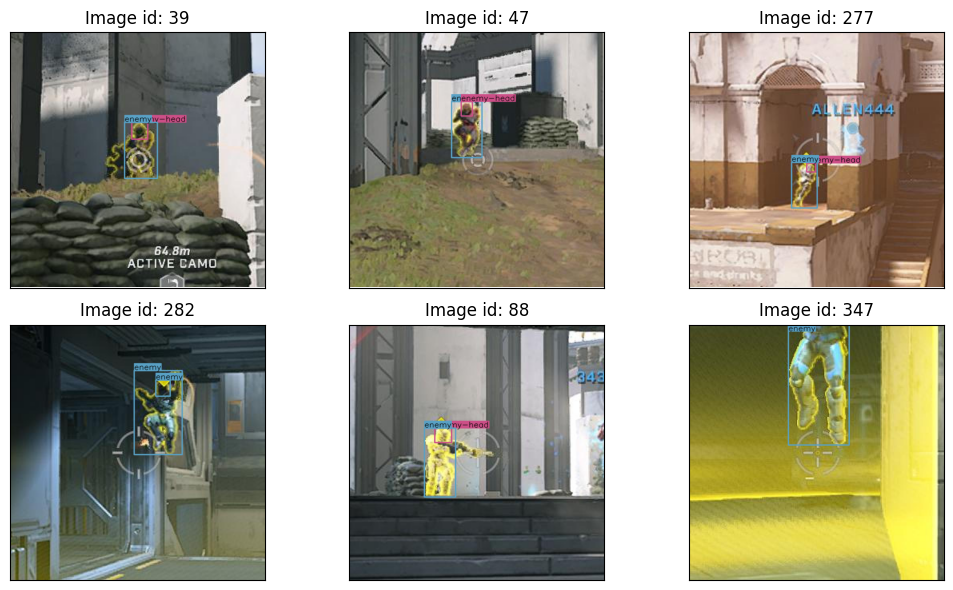

In [8]:
plot_examples(df_train)

## Dataset

In [9]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        # df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        df_images = pd.json_normalize(dataframe['image'])
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, w, h).
        """
        row = self.data.iloc[idx]
        # print(row)
        image = Image.open(io.BytesIO(row["bytes"]))
        # alx
        # image = row["image"]
        image = np.array(image)

        target = {}
        target["image_id"] = row["image_id"]

        labels = [row["category"]] if isinstance(row["category"], int) else row['category']
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label - 1 for label in labels]
        boxes = row['bbox'].tolist()

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)

        target['boxes'] = torch.tensor(np.array(boxes), dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        return image, target


def collate_fn(batch):
    batch = tuple(zip(*batch))
    images = torch.stack(batch[0])
    return images, batch[1]

## аументация

In [10]:
# Немного аугментаций
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Normalize(mean=mean, std=std),
        # HorizontalFlip меняет и ббоксы!
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format='coco', label_fields=['labels'])
)

test_transform = A.Compose(
    [
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
)

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Создадим Dataset для наших данных

## Конфигуратор

In [11]:
IS_BACKBONE_SIMPLE = True
IS_BACKBONE_UNFREEZE = False

IS_FPN_SIMPLE = True
IS_FPN_PYRAMID = False

IS_DETECTION_HEAD = True
IS_DECOUPLED_HEAD = False

IS_BBOXLOSS_SMOOTHL1 = False
IS_BBOXLOSS_DIOU = True

IS_LABEL_ASSIGN_1 = True
IS_LABEL_ASSIGN_TAL = False

## Backbone

### с  выключенными градиентами

In [12]:
class Backbone(nn.Module):
    def __init__(self, model_name="efficientnet_b0", out_indices=(-1, -2, -3)):
        super().__init__()
        # timm.list_models(pretrained=True)
        self.backbone = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=out_indices)
        # Выключаем градиенты у модели, чтобы упростить обучение
        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

### Backbone с параметром разморозки [1 балл]

В лекции мы заморозили все слои у модели. Вам нужно написать бекбоун с возможностью разморозки __k__ последних слоев или блоков (на ваш выбор).

In [13]:
class BackboneUnfreeze(nn.Module):
    def __init__(self, model_name="efficientnet_b0", out_indices=(-1, -2, -3), unfreeze_last=0):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=out_indices)

        for param in self.backbone.parameters():
            param.requires_grad = False

        if unfreeze_last > 0:
            layers = list(self.backbone.children())
            # Unfreeze the last N layers
            for layer in layers[-unfreeze_last:]:
                for param in layer.parameters():
                    param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

**Вывод**

Так как мы берем предобученную сеть, то разморозка нескольких слоев может повысить качество фичемапов, но увеличить время обучения модели.

## Neck

### Простая

In [14]:
class SimplifiedFPN(nn.Module):
    """Очень простая шея: один слой conv + batch_norm + activation. """

    def __init__(self, in_channels, out_channels, use_activations=True):
        super().__init__()
        self.fpn_conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.activation = nn.ReLU() if use_activations else nn.Identity()
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, features):
        return self.activation(self.bn(self.fpn_conv(features[0])))


### NECK [3 балла]  Feature Pyramid Network [2 балла]

Знакомая из лекции архитектура шеи:

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

#### Path Aggregation Network [3 балла]

Другая архитектура немного сложнее. Она содержит не только top-down путь, но ещё bottom-up путь:

<center><img src="https://i.ibb.co/k68BWBGv/path-aggregation-network.png" width="500"/></center>

* [Path Aggregation Network for Instance Segmentation](https://arxiv.org/abs/1803.01534)

Подробное описание архитектуры можно найти в секции 3 (Framework). Реализовывать adaptive feature pooling не нужно.


__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

### Структура скип - коннекторов
<pre>
Backbone layers:        C2    C3    C4    C5
                         ↓     ↓     ↓     ↓
Lateral connections:     ←     ←     ←     ←
                         ↓     ↓     ↓     ↓
Output features:         P2    P3    P4    P5
</pre>

**Процесс работы:**
- Сначала признаки из backbone (C2-C5) проходят через боковые (lateral) свертки для уменьшения количества каналов
- Затем происходит восходящий путь (top-down path):
    - Признаки с верхнего уровня интерполируются (увеличиваются) до размера нижнего уровня
    - Добавляются к боковым признакам через скип-коннектор
    - Результат проходит через дополнительную свертку для сглаживания

In [15]:
from typing import List, Dict, Optional


class FPN(nn.Module):
    """
    Feature Pyramid Network neck implementation.
    """

    def __init__(
            self,
            in_channels: int,
            out_channels: int,
            extra_blocks: Optional[nn.Module] = None,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # Боковые свертки для уменьшения каналов
        self.lateral_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0
        )

        # Свертки для сглаживания после скип-коннекторов
        self.output_conv = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1
        )

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        self.extra_blocks = extra_blocks

    def forward(self, features: List[torch.Tensor]) -> Dict[str, torch.Tensor]:

        # 1. Боковые свертки
        laterals = []
        for feature in features:
            laterals.append(self.lateral_conv(feature))

        # 2. Восходящий путь с скип-коннекторами
        used_backbone_levels = len(laterals)
        for i in range(used_backbone_levels - 1, 0, -1):
            # Upsample and add
            laterals[i - 1] += nn.functional.interpolate(
                laterals[i], scale_factor=2, mode="nearest"
            )

        outs = []
        for lateral in laterals:
            outs.append(self.output_conv(lateral))

        if self.extra_blocks is not None:
            outs = self.extra_blocks(outs)

        return {f"P{i}": out for i, out in enumerate(outs)}

**Вывод**

Преимущества использования скип-коннекторов:
- Сохранение детальной информации из ранних слоев
- Улучшение градиентов (менее угасают)
- Лучшее обнаружение объектов разных размеров


## Head [1 балл]

In [16]:

class DetectionHead(nn.Module):
    """ Двухсоставная голова, схематично выглядит следующим образом:
                      -> conv (cls) [B, NUM_ANCHORS * NUM_CLASSES, W, H]
        neck -> conv
                      -> conv (reg) [B, NUM_ACNHORS * 5, W, H]
    где число 5 обозначает 4 смещения для итогового + confidence score.
    """

    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.cls_head = nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=1)
        self.reg_head = nn.Conv2d(in_channels, num_anchors * 5, kernel_size=1)
        self.num_classes = num_classes

    def forward(self, x):
        x = F.relu(self.conv(x))
        cls_logits = self.cls_head(x)
        bbox_preds = self.reg_head(x)
        return cls_logits, bbox_preds

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно

In [17]:
class DecoupledHead(nn.Module):
    """ Decoupled Head from YOLOX.
    
    """

    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__()
        self.num_classes = num_classes

        #Начальный общий сверточный слой
        self.shared_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

        # Ветка классификации
        self.cls_branch = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=1)
        )

        # Ветка регрессии
        self.reg_branch = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, num_anchors * 5, kernel_size=1)  # 4 for bbox + 1 for confidence
        )

        # Инициализация весов
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.shared_conv(x)
        cls_logits = self.cls_branch(x)
        bbox_preds = self.reg_branch(x)
        return cls_logits, bbox_preds

**Вывод** 
- Отдельные ветки могут учить разные признаки для классификации и регрессии
- Каждая ветка имеет свой набор параметров, что позволяет лучше специализироваться
- Общий начальный слой помогает в изучении общих признаков

## Label assignment [2]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:

$$t = s^\alpha * u^\beta$$

где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.

2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [18]:
from torchvision.ops import box_iou


def compute_task_alignment_score(pred_boxes, target_boxes, pred_cls, target_cls, alpha=1.0, beta=6.0):
    """
    Compute task alignment score between predictions and targets.

    """
    # Convert boxes to (x_min, y_min, x_max, y_max) format
    pred_x1 = pred_boxes[..., 0]
    pred_y1 = pred_boxes[..., 1]
    pred_x2 = pred_boxes[..., 0] + pred_boxes[..., 2]
    pred_y2 = pred_boxes[..., 1] + pred_boxes[..., 3]

    target_x1 = target_boxes[..., 0]
    target_y1 = target_boxes[..., 1]
    target_x2 = target_boxes[..., 0] + target_boxes[..., 2]
    target_y2 = target_boxes[..., 1] + target_boxes[..., 3]

    # IoU
    pred_boxes_xyxy = torch.stack([pred_x1, pred_y1, pred_x2, pred_y2], dim=-1)
    target_boxes_xyxy = torch.stack([target_x1, target_y1, target_x2, target_y2], dim=-1)
    iou = box_iou(pred_boxes_xyxy, target_boxes_xyxy)

    # classification score
    cls_score = torch.sum(pred_cls * target_cls, dim=-1)

    # task alignment score
    alignment_score = (cls_score ** alpha) * (iou ** beta)

    return alignment_score

In [19]:
def assign_target_tal(anchors, gt_boxes, gt_labels, num_classes, pred_boxes=None, pred_cls=None,
                      pos_th=0.6, neg_th=0.3, alpha=1.0, beta=6.0):
    """
        pos_th: Positive threshold for IoU
        neg_th: Negative threshold for IoU
        alpha: Weight for classification score in TAL
        beta: Weight for localization score in TAL

    """
    num_anchors = anchors.shape[0]
    target_objectness = torch.zeros(num_anchors, device=anchors.device)
    target_offsets = torch.zeros((num_anchors, 4), device=anchors.device)
    target_cls = torch.zeros((num_anchors, num_classes), device=anchors.device)

    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls

    # Convert GT boxes to (x_min, y_min, x_max, y_max) format
    gt_xyxy = gt_boxes.clone()
    gt_xyxy[:, 2:] = gt_xyxy[:, :2] + gt_xyxy[:, 2:]

    # Calculate IoU between anchors and GT boxes
    ious = box_iou(anchors, gt_xyxy)

    # If we have predictions, use TAL to compute alignment scores
    if pred_boxes is not None and pred_cls is not None:
        alignment_scores = compute_task_alignment_score(
            pred_boxes, gt_boxes, pred_cls, F.one_hot(gt_labels, num_classes),
            alpha=alpha, beta=beta
        )
        # Use alignment scores instead of IoU for assignment
        best_score, best_gt_idx = alignment_scores.max(dim=1)
    else:
        # Fallback to IoU-based assignment
        best_iou, best_gt_idx = ious.max(dim=1)
        best_score = best_iou

    # Assign negative samples
    neg_mask = best_score < neg_th
    target_objectness[neg_mask] = 0

    # Assign positive samples
    pos_mask = best_score >= pos_th
    target_objectness[pos_mask] = 1

    # Assign ignore samples
    ignore_mask = (best_score >= neg_th) & (best_score < pos_th)
    target_objectness[ignore_mask] = -1

    # Assign regression targets for positive samples
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]
    for pos in pos_indices:
        gt_idx = best_gt_idx[pos]
        gt_box = gt_xyxy[gt_idx]
        anchor_box = anchors[pos]

        # Calculate target offsets
        target_offsets[pos] = get_target_offset(anchor_box, gt_box)
        target_cls[pos, gt_labels[gt_idx]] = 1

    # Ensure each GT has at least one positive anchor
    for gt_idx in range(gt_xyxy.shape[0]):
        if not ((target_objectness == 1) & (best_gt_idx == gt_idx)).any():
            # Find anchor with highest IoU for this GT
            best_anchor_idx = torch.argmax(ious[:, gt_idx])
            target_offsets[best_anchor_idx] = get_target_offset(anchors[best_anchor_idx], gt_xyxy[gt_idx])
            target_objectness[best_anchor_idx] = 1
            target_cls[best_anchor_idx, gt_labels[gt_idx]] = 1

    return target_offsets, target_objectness, target_cls


## DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \qquad \qquad y^I_1 = $$
$$x^I_2 = \qquad \qquad y^I_2 = $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Рассчитаем площадь выпуклой оболочки:**

Для расчета площади, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^С_1 = \qquad \qquad y^С_1 = $$
$$x^С_2 = \qquad \qquad y^С_2 = $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

$$C = (x^C_2 - x^C_1) * (y^C_2 - y^C_1)$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$d = $

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{C^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [20]:
class DIoULoss(nn.Module):
    """Distance Intersection over Union (DIoU) Loss.

    DIoU = IoU - (d^2 / c^2)

    """

    def __init__(self, reduction='mean'):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred_boxes, target_boxes):
        """
        Args:
            pred_boxes: Predicted boxes in format (x_min, y_min, w, h)
            target_boxes: Target boxes in format (x_min, y_min, w, h)
        Returns:
            DIoU loss
        """
        # Convert to (x_min, y_min, x_max, y_max) format
        pred_x1 = pred_boxes[..., 0]
        pred_y1 = pred_boxes[..., 1]
        pred_x2 = pred_boxes[..., 0] + pred_boxes[..., 2]
        pred_y2 = pred_boxes[..., 1] + pred_boxes[..., 3]

        target_x1 = target_boxes[..., 0]
        target_y1 = target_boxes[..., 1]
        target_x2 = target_boxes[..., 0] + target_boxes[..., 2]
        target_y2 = target_boxes[..., 1] + target_boxes[..., 3]

        # Calculate intersection area
        inter_x1 = torch.max(pred_x1, target_x1)
        inter_y1 = torch.max(pred_y1, target_y1)
        inter_x2 = torch.min(pred_x2, target_x2)
        inter_y2 = torch.min(pred_y2, target_y2)

        inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)

        # Calculate union area
        pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
        target_area = (target_x2 - target_x1) * (target_y2 - target_y1)
        union_area = pred_area + target_area - inter_area

        # Calculate IoU
        iou = inter_area / (union_area + 1e-16)

        # Calculate center distance
        pred_center_x = (pred_x1 + pred_x2) / 2
        pred_center_y = (pred_y1 + pred_y2) / 2
        target_center_x = (target_x1 + target_x2) / 2
        target_center_y = (target_y1 + target_y2) / 2

        center_distance = (pred_center_x - target_center_x) ** 2 + (pred_center_y - target_center_y) ** 2

        # Calculate diagonal length of the smallest enclosing box
        enclose_x1 = torch.min(pred_x1, target_x1)
        enclose_y1 = torch.min(pred_y1, target_y1)
        enclose_x2 = torch.max(pred_x2, target_x2)
        enclose_y2 = torch.max(pred_y2, target_y2)

        enclose_diagonal = (enclose_x2 - enclose_x1) ** 2 + (enclose_y2 - enclose_y1) ** 2

        # Calculate DIoU
        diou = iou - (center_distance / (enclose_diagonal + 1e-16))

        # Calculate loss
        loss = 1 - diou

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

## Detector

In [21]:
class Detector(nn.Module):
    """ Класс детектора, объединяющий все части вместе.

    Параметры
    ---------
    backbone_model_name : str
        Имя timm модели, которая будет исопльзоваться в качестве backbone
    neck_n_channels : int
        Итоговое количество каналов на выходе шеи
    num_classes : int
        Количество классов в датасете
    anchor_sizes : list, tuple
        Базовые размеры якорей. Используется методом `AnchorDetector` из
        `torchvision.models.detection.anchor_utils`для создания якорей.
    anchor_ratios : list, tuple
        Соотношения сторон якорей. Используется методом `AnchorDetector` из
        `torchvision.models.detection.anchor_utils`для создания якорей.
    input_size : tuple with length 2
        Размер входного изображения. Используется для расчета положения всех якорей.

    NOTE: На самом деле, AnchorDetector на вход ждет anchor_sizes и anchor_ratios как Tuple[Tuple[int]],
    это связано с возможностью создания разных якорей для разных выходов модели. Сейчас нам это не нужно,
    поэтому структура намеренно упрощена.
    """

    def __init__(self,
                 backbone_model_name="efficientnet_b0",
                 neck_n_channels=256,
                 num_classes=4,
                 anchor_sizes=(32, 64, 128),
                 anchor_ratios=(0.5, 1.0, 2.0),
                 input_size=(640, 640),
                 ):
        super().__init__()
        self.num_classes = num_classes
        # Создаем backbone с одним выходом, только из последнего слоя
        # Если нужно сделать несколько выходов, меняй out_indices
        if IS_BACKBONE_SIMPLE:
            self.backbone = Backbone(backbone_model_name, out_indices=(-1,))
        if IS_BACKBONE_UNFREEZE:
            self.backbone = BackboneUnfreeze(backbone_model_name, out_indices=(-1,), unfreeze_last=2)
        # Получаем количество фичемапов на выходном слое
        in_channels = self.backbone.backbone.feature_info.channels()[0]
        # Создаем шею, с учетом параметров, полученных выше
        if IS_FPN_SIMPLE:
            self.neck = SimplifiedFPN(in_channels, out_channels=neck_n_channels)
        # todo check
        if IS_FPN_PYRAMID:
            self.neck = FPN(in_channels, out_channels=neck_n_channels)
        # Размерность выходов головы зависит от количество якорей, поэтому сначала считаем количество якорей в каждой
        # ячейке выходной фичемапы
        num_anchors = len(anchor_sizes) * len(anchor_ratios)
        if IS_DETECTION_HEAD:
            self.head = DetectionHead(in_channels=neck_n_channels, num_anchors=num_anchors, num_classes=num_classes)
        if IS_DECOUPLED_HEAD:
            self.head = DecoupledHead(in_channels=neck_n_channels, num_anchors=num_anchors, num_classes=num_classes)

        # Генерируем якоря
        anchor_generator = AnchorGenerator(sizes=(anchor_sizes,), aspect_ratios=(anchor_ratios,))
        # Узнаем размер выходной фичемапы
        reduction = self.backbone.backbone.feature_info.reduction()[0]
        grid_sizes = [[input_size[0] // reduction, input_size[1] // reduction]]

        # Расчитываем координаты якорей в каждой точке выходной фичемапы.
        ###
        # Якоря хранятся в формате (x_min, y_min, x_max, y_max)!
        ###
        anchors = anchor_generator.grid_anchors(grid_sizes, strides=[[reduction, reduction]])
        anchors = torch.stack(anchors, dim=0)
        # Заранее считаем координаты якорей в формате (x_center, y_center, w, h)
        # Это пригодится для расчета лосса
        anchor_centers = (anchors[:, :, :2] + anchors[:, :, 2:]) / 2
        anchor_sizes = (anchors[:, :, 2:] - anchors[:, :, :2])

        self.register_buffer("anchors", anchors)
        self.register_buffer("anchor_centers", anchor_centers)
        self.register_buffer("anchor_sizes", anchor_sizes)

    def forward(self, x):
        # Пропускаем картинку через всю сеть
        features = self.backbone(x)
        neck_features = self.neck(features)
        cls_logits, bbox_preds = self.head(neck_features)

        # Преобразуем сырые выходы модели в формат, в котором будет удобно считать лосс
        # cls_logits - [N, NUM_ANCHORS * NUM_CLASSES, W, H]
        # bbox_preds - [N, NUM_ANCHORS * 5, W, H]
        N = x.shape[0]
        cls_logits = cls_logits.permute(0, 2, 3, 1).contiguous()
        cls_logits = cls_logits.view(N, -1, self.head.num_classes)  # [N, NUM_ANCHORS * W * H, NUM_CLASSES]

        bbox_preds = bbox_preds.permute(0, 2, 3, 1).contiguous()
        bbox_preds = bbox_preds.view(N, -1, 5)  # [N, NUM_ANCHORS * W * H, 5]
        bbox_offsets = bbox_preds[:, :, :4]
        confidence_logits = bbox_preds[:, :, 4]

        if self.training:
            # В процессе тренировки возвращаем просто смещения и логиты
            return bbox_offsets, confidence_logits, cls_logits

        # Если мы делаем предсказание, сразу считаем итоговый ббокс и вероятности
        # Модель предсказывает ббоксы в формате (x_min, y_min, w, h)
        bboxes = self.decode_bboxes(bbox_offsets)
        confidence = torch.sigmoid(confidence_logits)
        cls_probs = torch.softmax(cls_logits, dim=-1)
        return bboxes, confidence, cls_probs

    def decode_bboxes(self, bbox_offsets):
        """Используя предсказанные смещения, считаем предсказанные ббоксы по формулам из YOLOv3.

        Боксы возвращаются в формате (x_min, y_min, w, h).
        """
        tx = bbox_offsets[:, :, 0]
        ty = bbox_offsets[:, :, 1]
        tw = bbox_offsets[:, :, 2]
        th = bbox_offsets[:, :, 3]

        center_x = self.anchor_centers[:, :, 0] + torch.sigmoid(tx) * self.anchor_sizes[:, :, 0]
        center_y = self.anchor_centers[:, :, 1] + torch.sigmoid(ty) * self.anchor_sizes[:, :, 1]

        w = torch.exp(tw) * self.anchor_sizes[:, :, 0]
        h = torch.exp(th) * self.anchor_sizes[:, :, 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2
        return torch.stack([x_min, y_min, w, h], dim=-1)

In [22]:
def safe_logit(x):
    """ Безопасный расчет logit'ов. """
    eps = 1e-6
    x = torch.clamp(x, eps, 1 - eps)
    return torch.log(x / (1 - x))


def get_target_offset(anchor_box, gt_box):
    """ Расчитываем таргет как желаемые смещения от якорей до GT.

    anchor_box: torch.Tensor в формате (x_min, y_min, x_max, y_max),
    gt_box: torch.Tensor в формате (x_min, y_min, x_max, y_max).
    """
    # Конвертируем GT в формат (x_center, y_center), (w, h)
    gt_center = (gt_box[:2] + gt_box[2:]) / 2
    gt_size = gt_box[2:] - gt_box[:2]

    # Конвертируем якоря в формат (x_center, y_center), (w, h)
    anchor_center = (anchor_box[:2] + anchor_box[2:]) / 2
    anchor_size = anchor_box[2:] - anchor_box[:2]

    # Вычисляем значения смещений для положительных ббоксов
    tx = (gt_center[0] - anchor_center[0]) / anchor_size[0]
    ty = (gt_center[1] - anchor_center[1]) / anchor_size[1]
    target_tx = safe_logit(tx)
    target_ty = safe_logit(ty)

    target_tw = torch.log(gt_size[0] / anchor_size[0])
    target_th = torch.log(gt_size[1] / anchor_size[1])
    return torch.tensor([target_tx, target_ty, target_tw, target_th]).to(anchor_box.device)

In [23]:
# def get_target_offset(anchor_box, gt_box):
#     """
#     Calculate target offsets between anchor and ground truth box.
#
#     Args:
#         anchor_box: Anchor box in format (x_min, y_min, x_max, y_max)
#         gt_box: Ground truth box in format (x_min, y_min, x_max, y_max)
#
#     Returns:
#         Target offsets (tx, ty, tw, th)
#     """
#     # Convert to center, width, height format
#     anchor_center_x = (anchor_box[0] + anchor_box[2]) / 2
#     anchor_center_y = (anchor_box[1] + anchor_box[3]) / 2
#     anchor_width = anchor_box[2] - anchor_box[0]
#     anchor_height = anchor_box[3] - anchor_box[1]
#
#     gt_center_x = (gt_box[0] + gt_box[2]) / 2
#     gt_center_y = (gt_box[1] + gt_box[3]) / 2
#     gt_width = gt_box[2] - gt_box[0]
#     gt_height = gt_box[3] - gt_box[1]
#
#     # Calculate offsets
#     tx = (gt_center_x - anchor_center_x) / anchor_width
#     ty = (gt_center_y - anchor_center_y) / anchor_height
#     tw = torch.log(gt_width / anchor_width)
#     th = torch.log(gt_height / anchor_height)
#
#     return torch.tensor([tx, ty, tw, th], device=anchor_box.device)

In [24]:
def assign_target(anchors, gt_boxes, gt_labels, num_classes, pos_th=0.6, neg_th=0.3):
    """ Для каждого GT находим якоря, которые будут участвовать в расчете лосса по следующему алгоритму:
    1. Положительные якоря - якоря у которых IoU с GT >= `pos_th`,
    2. Игнорируемые якоря - `neg_th` <= IoU c GT < `pos_th`,
    3. Отрицательные якоря - IoU c GT < `neg_th`.
    4. Если для GT не нашлось ни одного якоря, назначаем GT якорь с самым большим IoU.

    Параметры
    ---------
    anchors : list[list[float]]
        Набор якорей для выходной фичемапы, размер (NUM_ANCHORS * W * H, 4)
    gt_boxes : list[list[float]]
        Набор истинных ббоксов на изображении, размер (N_GT, 4)
    gt_labels : list[int]
        Набор лейблов для GT, размер (N_GT, )
    num_classes : int
        Количество классов в датасете
    pos_th : float
        Минимальная граница по IoU между якорем и GT после которой якорь считается положительным.
    neg_th : float
        Верхняя граница по IoU между якорем и GT когда якорь считается отрицательным.

    Returns
    -------
    target_offsets: Массив, содержащий истинные смещения для положительных якорей, 0 для всех остальных
    target_objectness: Массив, содержащий тип каждого якоря (1 - положительный, 0 - отрицательный, -1 - игнорируемый)
    target_cls: Массив, содержащий ohe классы для каждого якоря. Для всех, кроме положительных якорей, класс не указан.
    """
    num_anchors = anchors.shape[0]
    target_objectness = torch.zeros(num_anchors, device=anchors.device)
    target_offsets = torch.zeros((num_anchors, 4), device=anchors.device)
    target_cls = torch.zeros((num_anchors, num_classes), device=anchors.device)
    # Если на изображении нет объектов, возвращаем пустые списки
    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls
    # box_iou работает с форматом ббоксов (x_min, y_min, x_max, y_max)
    # Якоря находятся в нужном формате, а GT - нет, тк имеет формат (x_min, y_min, w, h)
    # Переведем GT боксы в нужный формат
    gt_xyxy = gt_boxes.clone()
    gt_xyxy[:, 2:] = gt_xyxy[:, :2] + gt_xyxy[:, 2:]
    # Считаем iou между всеми якорями и всеми GT
    ious = box_iou(anchors, gt_xyxy)  # [num_anchors, num_gt]
    # Находим самый оптимальный GT для каждого якоря
    best_iou, best_gt_idx = ious.max(dim=1)
    # Отмечаем якоря, которые будут пропущены при расчете лосса
    ignore_mask = (best_iou >= neg_th) & (best_iou < pos_th)
    target_objectness[ignore_mask] = -1

    # Отмечаем якоря, для которых будет считаться локализационный лосс
    pos_mask = best_iou >= pos_th
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]
    for pos in pos_indices:
        gt_idx = best_gt_idx[pos]
        gt_box = gt_xyxy[gt_idx]
        anchor_box = anchors[pos]

        target_offsets[pos] = get_target_offset(anchor_box, gt_box)
        target_objectness[pos] = 1
        target_cls[pos, gt_labels[gt_idx]] = 1

    # Присваиваем предсказание с самым большим IoU для GT
    # у которых не нашлось ни оного предсказания
    for gt_idx in range(gt_xyxy.shape[0]):
        if not ((target_objectness == 1) & (best_gt_idx == gt_idx)).any():
            best_anchor_idx = torch.argmax(ious[:, gt_idx])
            target_offsets[best_anchor_idx] = get_target_offset(anchors[best_anchor_idx], gt_xyxy[gt_idx])
            target_objectness[best_anchor_idx] = 1
            target_cls[best_anchor_idx, gt_labels[gt_idx]] = 1
    return target_offsets, target_objectness, target_cls

In [25]:
class ComputeLoss:
    """ Базовый расчет лосса.

    Параметры
    ---------
    bbox_loss : Локализационная часть лосса
    obj_loss : Лосс для Confidence score
    cls_loss : Классификационная часть лосса
    weight_bbox, weight_obj, weight_cls : Константы для баллансировки частей лосса
    """

    def __init__(self,
                 bbox_loss=None, obj_loss=None, cls_loss=None,
                 weight_bbox=5, weight_obj=1, weight_cls=1
                 ):
        self.bbox_loss = nn.SmoothL1Loss() if bbox_loss is None else bbox_loss
        self.obj_loss = nn.BCEWithLogitsLoss() if obj_loss is None else obj_loss
        self.cls_loss = nn.BCEWithLogitsLoss() if cls_loss is None else cls_loss
        self.weight_bbox = weight_bbox
        self.weight_obj = weight_obj
        self.weight_cls = weight_cls

    def __call__(self, predicts, targets):
        """ Расчет лосса для пары (предсказание, таргет)

        Параметры
        ---------
        predicts : Предсказания модели для одной картинки: Смещения, objectness score и логиты для классов
        targets : Gt значения для расчета лосса, а именно: GT смещения, GT objectness score и GT ohe классы
        """
        pred_offsets, pred_obj_logits, pred_cls_logits = predicts
        target_boxes, target_obj, target_cls = targets
        # Confidence score считается только для предсказаний соотв отрицательным и положительным якорям
        valid_mask = target_obj != -1
        loss_obj = self.obj_loss(pred_obj_logits[valid_mask], target_obj[valid_mask])

        # Локализационная и классификационные части считаются для предсказаинй соотв положительным якорям
        pos_mask = target_obj == 1
        if pos_mask.sum() > 0:
            loss_cls = self.cls_loss(pred_cls_logits[pos_mask], target_cls[pos_mask])
            loss_bbox = self.bbox_loss(pred_offsets[pos_mask], target_boxes[pos_mask])
        else:
            loss_cls = torch.tensor(0.0, device=pred_offsets.device)
            loss_bbox = torch.tensor(0.0, device=pred_offsets.device)
        return self.weight_bbox * loss_bbox + self.weight_obj * loss_obj + self.weight_cls * loss_cls

## Runner

In [26]:
class Runner:
    """ Базовый класс для обучения и валидации модели.

    Параметры
    ---------
    model : torch модель, которая будет обучаться.
    compute_loss : экземпляр класса ComputeLoss (или другого с реализованным методом __call__).
    optimizer : torch optimizer
    train_dataloader : torch dataloader семплирующий данные для обучения модели.
    assign_target_method : callable, который решает задачу сопоставления якорей и таргета (например, assign_target)
    deivce : девайс на котором будет происходить обучения, по дефолту "cpu"
    scheduler : torch scheduler
    assign_target_kwargs : доп параметры для функции в `assign_target_method`,
    val_dataloader : torch dataloader загружающий валидационные данные.
    score_threshold : При расчете метрики на валидации, все предсказания,
        с (confidence score * cls_probs) < score_threshold будут проигнорированны.
    nms_threshold : Предсказания, имеющие пересечение по IoU >= nms_threshold будут считаться одним предсказанием.
    max_boxes_per_cls : Максимальное количество ббоксов на изображение для одного класса после фильтрации по `score_threshold`.
    """

    def __init__(self, model, compute_loss, optimizer, train_dataloader, assign_target_method, device=None,
                 scheduler=None, assign_target_kwargs=None,
                 val_dataloader=None, val_every=5, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8):
        self.model = model
        self.compute_loss = compute_loss
        self.optimizer = optimizer
        self.train_dataloader = train_dataloader
        assign_target_kwargs = {} if assign_target_kwargs is None else assign_target_kwargs
        self.assign_target_method = partial(assign_target_method, **assign_target_kwargs)
        self.device = "cpu" if device is None else device
        self.scheduler = scheduler

        # Валидационные параметры
        self.val_dataloader = val_dataloader
        self.val_every = val_every
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold
        self.max_boxes_per_cls = max_boxes_per_cls

        # Вспомогательные массивы
        self.batch_loss = []
        self.epoch_loss = []
        self.val_metric = []

    def _run_train_epoch(self, dataloader, verbose=True):
        """ Обучить модель одну эпоху на данных из `dataloader` """
        self.model.train()
        batch_loss = []
        for images, targets in (pbar := tqdm(dataloader, desc=f"Process train epoch", leave=False)):
            images = images.to(self.device)
            outputs = self.model(images)

            anchors = self.model.anchors.view(-1, 4)
            accum_loss = 0.0
            for ix in range(images.shape[0]):
                gt_boxes = targets[ix]['boxes'].to(self.device)
                gt_labels = targets[ix]['labels'].to(self.device)
                # выбираем какие якоря будут использоваться при расчете лосса.
                assigned_targets = self.assign_target_method(anchors, gt_boxes, gt_labels,
                                                             num_classes=model.num_classes)
                # Считаем лосс на основании предсказаний модели и таргетов.
                outputs_ixs = [out[ix] for out in outputs]
                loss = self.compute_loss(outputs_ixs, assigned_targets)
                accum_loss += loss
            accum_loss = accum_loss / images.shape[0]
            batch_loss.append(accum_loss.cpu().detach().item())

            # Делаем шаг оптимизатора после расчета лосса для всех элементов батча
            self.optimizer.zero_grad()
            accum_loss.backward()
            self.optimizer.step()
            # Обновляем описание tqdm бара усредненным значением лосса за предыдущй батч
            if verbose:
                pbar.set_description(f"Current batch loss: {batch_loss[-1]:.4}")
        return batch_loss

    def train(self, num_epochs=10, verbose=True):
        """ Обучаем модель заданное количество эпох. """
        val_desc = ""
        for epoch in (epoch_pbar := tqdm(range(1, num_epochs + 1), desc="Train epoch", total=num_epochs)):
            # Обучаем модель одну эпоху
            loss = self._run_train_epoch(self.train_dataloader, verbose=verbose)
            self.batch_loss.extend(loss)
            self.epoch_loss.append(np.mean(self.batch_loss[-len(self.train_dataloader):]))

            # Делаем валидацию, если был передан валидационный датасет
            if self.val_dataloader is not None and epoch % self.val_every == 0:
                val_metric = self.validate()
                self.val_metric.append(val_metric)
                val_desc = f" Val {val_metric:.4}"

            # Обновляем описание tqdm бара усредненным значением лосса за предыдую эпоху
            if verbose:
                epoch_pbar.set_description(f"Last epoch loss: Train {self.epoch_loss[-1]:.4}" + val_desc)
            # Делаем шаг scheduler'a если он был передан
            if self.scheduler is not None:
                self.scheduler.step()

    @torch.no_grad()
    def validate(self, dataloader=None):
        """ Метод для валидации модели. Если dataloader не передан, будет использоваться self.val_dataloder.
        Возвращает mAP (0.5 ... 0.95).
        """
        self.model.eval()
        dataloader = self.val_dataloader if dataloader is None else dataloader
        # Считаем метрику mAP с помощью функции из torchmetrics
        metric = MeanAveragePrecision(box_format="xywh", iou_type="bbox")
        for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
            images = images.to(self.device)
            outputs = self.model(images)
            predicts = _filter_predictions(outputs, self.score_threshold, self.nms_threshold,
                                           max_boxes_per_cls=self.max_boxes_per_cls, return_type="torch")
            metric.update(predicts, targets)
        return metric.compute()["map"].item()

    def plot_loss(self, row_figsize=3):
        self.val_metric = False # todo check
        nrows = 2 if self.val_metric else 1
        _, ax = plt.subplots(nrows, 1, figsize=(12, row_figsize * nrows), tight_layout=True)
        ax = np.array([ax]) if not isinstance(ax, np.ndarray) else ax
        ax[0].plot(self.batch_loss, label="Train batch Loss", color="tab:blue")
        ax[0].plot(np.arange(1, len(self.batch_loss) + 1, len(self.train_dataloader)), self.epoch_loss,
                   color="tab:orange", label="Train epoch Loss")
        ax[0].grid()
        ax[0].set_title("Train Loss")
        ax[0].set_xlabel("Number of Iterations")
        ax[0].set_ylabel("Loss")
        if self.val_metric:
            ax[1].plot(np.arange(self.val_every, len(self.batch_loss) + 1, len(self.val_dataloader) * self.val_every),
                       np.array(self.val_metric) * 100, color="tab:green", label="Validation mAP")
            ax[1].grid()
            ax[1].set_title("Valiation mAP")
            ax[1].set_xlabel("Number of Iterations")
            ax[1].set_ylabel("mAP (%)")
        plt.legend()
        plt.show()


def _filter_predictions(predictions, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8, return_type="list"):
    """ Ббоксы в `predictions` должны быть в формате (x_min, y_min, w, h). """
    # Итоговый скор считается как произведение уверенности модели в том что в данном якоре
    # и вероятность каждого класса в данном якоре.
    bboxes, confidences, cls_probs = predictions
    all_final_scores = confidences[:, :, None] * cls_probs

    num_classes = cls_probs.shape[-1]
    final_predictions = []
    # Для каждого элемента в `predictions` независимо выбираем ббоксы и скоры
    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {"boxes": [], "labels": [], "scores": []}

        # Для каждого класса отдельно фильтруем ббоксы с помощью NMS
        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            # Фильтруем ббоксы, score которых меньше порога
            keep_ixs = cls_scores > score_threshold
            if keep_ixs.sum() == 0:
                continue
            cls_boxes = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]

            # Если предсказаний слишком много, выбираем только самые уверенные
            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            # Конвертируем ббоксы в формат x_min, y_min, x_max, y_max
            boxes_xyxy = cls_boxes.clone()
            boxes_xyxy[:, 2:] = boxes_xyxy[:, :2] + boxes_xyxy[:, 2:]
            # Запускаем NMS по всем оставшимся ббоксам класса cls
            pred_ixs = nms(boxes_xyxy, cls_scores, nms_threshold)
            # Сохраняем все предсказания для класса cls
            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].cpu().tolist())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].item())
        if return_type == "torch":
            for key, item in preds.items():
                preds[key] = torch.tensor(item)
        elif return_type != "list":
            raise ValueError(f"Received unexpected `return_type`. Could be either `torch` or `list`, not {return_type}")
        final_predictions.append(preds)
    return final_predictions

In [27]:
train_dataset = HaloDataset(df_train, transform=train_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

In [28]:
# batch_size=64
batch_size=4

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=9, shuffle=False, collate_fn=collate_fn)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 1e-3

model = Detector("resnetv2_101", num_classes=4, anchor_sizes=(30, 50, 140, 300), anchor_ratios=(0.5, 1, 1.6, 2)).to(
    device)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=5e-5)

if IS_BBOXLOSS_SMOOTHL1:
    bbox_loss = nn.SmoothL1Loss()
if IS_BBOXLOSS_DIOU:
    bbox_loss = DIoULoss()

bce_loss = nn.BCEWithLogitsLoss()

compute_loss = ComputeLoss(bbox_loss, bce_loss, bce_loss, weight_bbox=10)


if IS_LABEL_ASSIGN_1:
    assign_target_fn = assign_target
    assign_target_kwargs = {"neg_th":0.4, "pos_th":0.6}

if IS_LABEL_ASSIGN_TAL:
    assign_target_fn = assign_target_tal
    assign_target_kwargs = {
        "neg_th": 0.4,
        "pos_th": 0.6,
        "alpha": 1.0,  # Вес для классификации
        "beta": 6.0  # Вес для локализации
    }
runner = Runner(model, compute_loss, optimizer, train_dataloader, assign_target_fn, device=device,
                scheduler=scheduler, assign_target_kwargs=assign_target_kwargs,
                val_dataloader=test_dataloader)

num_epochs = 50

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

## train

In [30]:
runner.train(num_epochs=num_epochs, verbose=True)

Train epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

...

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Running validation:   0%|          | 0/16 [00:00<?, ?it/s]

## Результаты обучения


ValueError: x and y must have same first dimension, but have shapes (10,) and (20,)

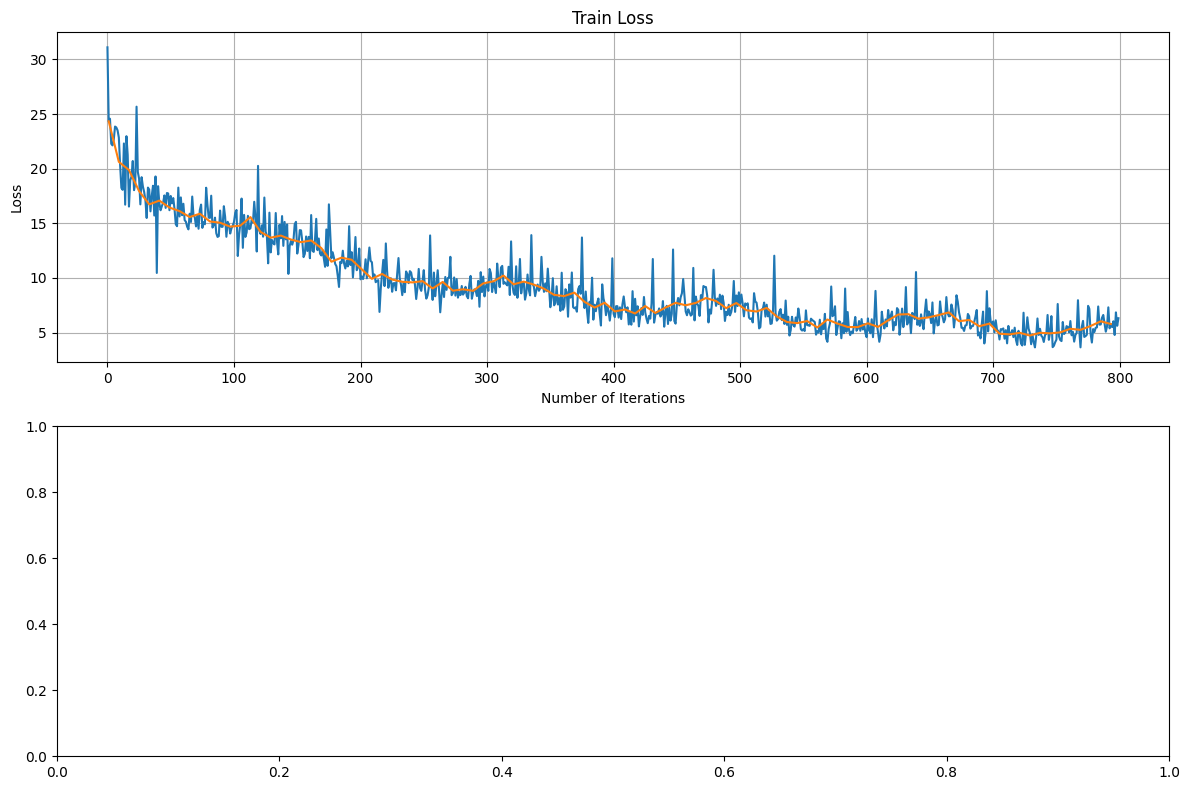

In [44]:
runner.plot_loss(row_figsize=4)

### Smouf

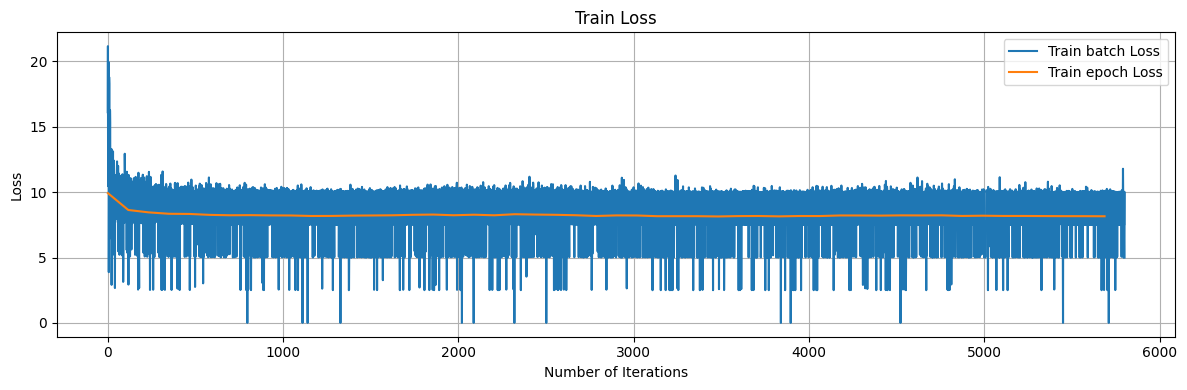

In [31]:
runner.plot_loss(row_figsize=4)